# Notebook 03: Baseline Models (Proper Version)
Opx ML Thermobarometer
Author: [Your name]
Date: 2026-04-04

This notebook trains baseline regression models for temperature and pressure using orthopyroxene-only and orthopyroxene-liquid data, with proper hyperparameter tuning, KD equilibrium filtering, and comprehensive evaluation.

In [1]:
%matplotlib inline
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
from config import (ROOT, DATA_RAW, DATA_PROC, DATA_SPLITS, DATA_NATURAL,
                    MODELS, FIGURES, RESULTS, LOGS, EXPETDB)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, RandomizedSearchCV, GroupShuffleSplit
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib, copy, warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

## 3.1 Load data and apply KD equilibrium filter

In [2]:
# Load core dataset
df = pd.read_csv(DATA_PROC / 'opx_clean_core.csv')
print(f'Loaded core dataset: {len(df)} rows')

# Load liquid data
liq_raw = pd.read_excel(EXPETDB, sheet_name='Liquid')
liq = liq_raw[['Experiment'] + [f'{o} value' for o in ['SiO2','TiO2','Al2O3','FeO','MgO','CaO','Na2O','K2O']]].copy()
liq.columns = ['Experiment'] + [f'liq_{o}' for o in ['SiO2','TiO2','Al2O3','FeO','MgO','CaO','Na2O','K2O']]
for c in [f'liq_{o}' for o in ['SiO2','TiO2','Al2O3','FeO','MgO','CaO','Na2O','K2O']]:
    liq[c] = pd.to_numeric(liq[c], errors='coerce')

# Dedup: prefer liquid row with oxide total closest to 100
liq_cols = [f'liq_{o}' for o in ['SiO2','TiO2','Al2O3','FeO','MgO','CaO','Na2O','K2O']]
liq['_total'] = liq[liq_cols].sum(axis=1, min_count=5)
liq['_dist_100'] = (liq['_total'] - 100).abs()
liq = liq.sort_values(['Experiment', '_dist_100']).drop_duplicates(subset='Experiment', keep='first')
liq = liq.drop(columns=['_total', '_dist_100'])

# Merge and compute KD filter
df_liq = df.merge(liq, on='Experiment', how='inner')
mw_MgO, mw_FeO = 40.304, 71.844
df_liq['FeMg_opx'] = (df_liq['FeO_total']/mw_FeO) / (df_liq['MgO']/mw_MgO)
df_liq['FeMg_liq'] = (df_liq['liq_FeO']/mw_FeO) / (df_liq['liq_MgO']/mw_MgO)
df_liq['KD_FeMg'] = df_liq['FeMg_opx'] / df_liq['FeMg_liq']

n_before = len(df_liq)
df_liq = df_liq[(df_liq['KD_FeMg'] >= 0.23) & (df_liq['KD_FeMg'] <= 0.35)]
print(f'KD filter: {n_before} -> {len(df_liq)} opx-liquid pairs')

df_liq['liq_Mg_num'] = (df_liq['liq_MgO']/mw_MgO) / (df_liq['liq_MgO']/mw_MgO + df_liq['liq_FeO']/mw_FeO)
df_liq = df_liq.dropna(subset=['liq_SiO2','liq_Al2O3','liq_FeO','liq_MgO','liq_CaO','liq_Mg_num'])
print(f'After dropna: {len(df_liq)} opx-liquid pairs, {df_liq["Citation"].nunique()} studies')

Loaded core dataset: 1148 rows
KD filter: 993 -> 615 opx-liquid pairs
After dropna: 609 opx-liquid pairs, 93 studies


## 3.2 Define features and train/test split

In [3]:
# Feature definitions
OPX_FEAT = ['SiO2','Al2O3','FeO_total','MgO','CaO','Mg_num','Al_IV','Al_VI','En_frac','Fs_frac','Wo_frac','MgTs']
LIQ_OXIDES = ['SiO2','TiO2','Al2O3','FeO','MgO','CaO','Na2O','K2O']
liq_feat = [f'liq_{o}' for o in LIQ_OXIDES] + ['liq_Mg_num']
ALL_FEAT = OPX_FEAT + liq_feat

# Base models
base_models = {
    'RF':  RandomForestRegressor(random_state=42, n_jobs=-1),
    'ERT': ExtraTreesRegressor(random_state=42, n_jobs=-1),
    'XGB': XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
    'GB':  GradientBoostingRegressor(random_state=42),
}

# Parameter grids for RandomizedSearchCV
param_grids = {
    'RF': {
        'n_estimators': [200, 500, 800],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2', 0.5, 0.8],
    },
    'ERT': {
        'n_estimators': [200, 500, 800],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2', 0.5, 0.8],
    },
    'XGB': {
        'n_estimators': [200, 500, 800],
        'max_depth': [6, 8, 10],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.8, 0.9, 1.0],
        'colsample_bytree': [0.8, 0.9, 1.0],
        'reg_alpha': [0, 0.1, 1],
        'reg_lambda': [1, 1.5, 2],
    },
    'GB': {
        'n_estimators': [200, 500, 800],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.8, 0.9, 1.0],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
    },
}

## 3.3 Train/test split

In [4]:
# OPX-only split (grouped by Citation)
X_opx = df[OPX_FEAT].values
y_T_opx, y_P_opx = df['T_C'].values, df['P_kbar'].values
groups_opx = df['Citation'].values

gss_opx = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_opx, te_opx = next(gss_opx.split(X_opx, y_T_opx, groups=groups_opx))
Xtr_opx, Xte_opx = X_opx[tr_opx], X_opx[te_opx]
yTtr_opx, yTte_opx = y_T_opx[tr_opx], y_T_opx[te_opx]
yPtr_opx, yPte_opx = y_P_opx[tr_opx], y_P_opx[te_opx]
idx_tr_opx = df.index.values[tr_opx]
idx_te_opx = df.index.values[te_opx]

assert set(df.loc[idx_tr_opx, 'Citation']).isdisjoint(set(df.loc[idx_te_opx, 'Citation'])), \
    'Study leakage in opx-only split'
print(f'OPX-only: Train {len(Xtr_opx)} rows / {df.loc[idx_tr_opx, "Citation"].nunique()} studies, '
      f'Test {len(Xte_opx)} rows / {df.loc[idx_te_opx, "Citation"].nunique()} studies')

# OPX-liquid split (grouped by Citation)
X_liq = df_liq[ALL_FEAT].fillna(0).values
y_T_liq, y_P_liq = df_liq['T_C'].values, df_liq['P_kbar'].values
groups_liq = df_liq['Citation'].values

gss_liq = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_liq, te_liq = next(gss_liq.split(X_liq, y_T_liq, groups=groups_liq))
Xtr_liq, Xte_liq = X_liq[tr_liq], X_liq[te_liq]
yTtr_liq, yTte_liq = y_T_liq[tr_liq], y_T_liq[te_liq]
yPtr_liq, yPte_liq = y_P_liq[tr_liq], y_P_liq[te_liq]
idx_tr_liq = df_liq.index.values[tr_liq]
idx_te_liq = df_liq.index.values[te_liq]

assert set(df_liq.loc[idx_tr_liq, 'Citation']).isdisjoint(set(df_liq.loc[idx_te_liq, 'Citation'])), \
    'Study leakage in opx-liq split'
print(f'OPX-liquid: Train {len(Xtr_liq)} rows / {df_liq.loc[idx_tr_liq, "Citation"].nunique()} studies, '
      f'Test {len(Xte_liq)} rows / {df_liq.loc[idx_te_liq, "Citation"].nunique()} studies')

# Save indices
np.save(DATA_SPLITS / 'test_indices_opx.npy', idx_te_opx)
np.save(DATA_SPLITS / 'train_indices_opx.npy', idx_tr_opx)
np.save(DATA_SPLITS / 'test_indices_opx_liq.npy', idx_te_liq)
np.save(DATA_SPLITS / 'train_indices_opx_liq.npy', idx_tr_liq)

# Save opx-liq dataset for downstream notebooks
df_liq.to_parquet(DATA_PROC / 'opx_clean_opx_liq.parquet')
print(f'Saved opx-liq parquet: {len(df_liq)} rows')

OPX-only: Train 870 rows / 100 studies, Test 278 rows / 26 studies
OPX-liquid: Train 439 rows / 74 studies, Test 170 rows / 19 studies
Saved opx-liq parquet: 609 rows


## 3.4 Hyperparameter tuning

In [5]:
def tune_and_evaluate(X_train, X_test, y_train, y_test, model_name, target_name, model_type,
                      n_train_studies=None, n_test_studies=None):
    base_model = base_models[model_name]
    param_grid = param_grids[model_name]
    
    search = RandomizedSearchCV(
        base_model, param_grid,
        n_iter=50, cv=5,
        scoring='neg_mean_squared_error',
        random_state=42, n_jobs=-1
    )
    search.fit(X_train, y_train)
    best_model = search.best_estimator_
    
    print(f'{model_name} best params: {search.best_params_}')
    
    p_tr = best_model.predict(X_train)
    p_te = best_model.predict(X_test)
    
    rmse_tr = np.sqrt(mean_squared_error(y_train, p_tr))
    rmse_te = np.sqrt(mean_squared_error(y_test, p_te))
    mae_te = mean_absolute_error(y_test, p_te)
    r2_te = r2_score(y_test, p_te)
    
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = []
    for train_idx, val_idx in kf.split(X_train):
        model_cv = copy.deepcopy(best_model)
        model_cv.fit(X_train[train_idx], y_train[train_idx])
        p_cv = model_cv.predict(X_train[val_idx])
        cv_scores.append(np.sqrt(mean_squared_error(y_train[val_idx], p_cv)))
    cv_mean, cv_std = np.mean(cv_scores), np.std(cv_scores)
    
    joblib.dump(best_model, MODELS / f'model_{model_name}_{target_name}_{model_type}.joblib')
    
    return {
        'target': target_name,
        'model': model_name,
        'model_type': model_type,
        'rmse_train': rmse_tr,
        'rmse_test': rmse_te,
        'mae_test': mae_te,
        'r2_test': r2_te,
        'cv_rmse_mean': cv_mean,
        'cv_rmse_std': cv_std,
        'train_test_ratio': rmse_tr / rmse_te,
        'best_params': search.best_params_,
        'n_train_studies': n_train_studies,
        'n_test_studies': n_test_studies,
        'y_test': y_test,
        'p_test': p_te,
    }

# Study counts
n_tr_opx_studies = df.loc[idx_tr_opx, 'Citation'].nunique()
n_te_opx_studies = df.loc[idx_te_opx, 'Citation'].nunique()
n_tr_liq_studies = df_liq.loc[idx_tr_liq, 'Citation'].nunique()
n_te_liq_studies = df_liq.loc[idx_te_liq, 'Citation'].nunique()

all_results = []

print('\n=== OPX-ONLY TEMPERATURE ===')
for name in base_models:
    result = tune_and_evaluate(Xtr_opx, Xte_opx, yTtr_opx, yTte_opx, name, 'T_C', 'opx_only',
                               n_tr_opx_studies, n_te_opx_studies)
    all_results.append(result)

print('\n=== OPX-ONLY PRESSURE ===')
for name in base_models:
    result = tune_and_evaluate(Xtr_opx, Xte_opx, yPtr_opx, yPte_opx, name, 'P_kbar', 'opx_only',
                               n_tr_opx_studies, n_te_opx_studies)
    all_results.append(result)

print('\n=== OPX-LIQUID TEMPERATURE ===')
for name in base_models:
    result = tune_and_evaluate(Xtr_liq, Xte_liq, yTtr_liq, yTte_liq, name, 'T_C', 'opx_liq',
                               n_tr_liq_studies, n_te_liq_studies)
    all_results.append(result)

print('\n=== OPX-LIQUID PRESSURE ===')
for name in base_models:
    result = tune_and_evaluate(Xtr_liq, Xte_liq, yPtr_liq, yPte_liq, name, 'P_kbar', 'opx_liq',
                               n_tr_liq_studies, n_te_liq_studies)
    all_results.append(result)


=== OPX-ONLY TEMPERATURE ===
RF best params: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 10}
ERT best params: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 10}
XGB best params: {'subsample': 0.8, 'reg_lambda': 2, 'reg_alpha': 0.1, 'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
GB best params: {'subsample': 0.8, 'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 3, 'learning_rate': 0.01}

=== OPX-ONLY PRESSURE ===
RF best params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 20}
ERT best params: {'n_estimators': 800, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': None}
XGB best params: {'subsample': 0.8, 'reg_lambda': 2, 'reg_alpha': 0.1, 'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.01, 'col

## 3.5 Save results and create summary table

In [6]:
# Save all results
results_df = pd.DataFrame(all_results)
results_df.to_csv(RESULTS / 'nb03_results_all.csv', index=False)

summary_cols = ['target', 'model', 'model_type', 'rmse_train', 'rmse_test', 'mae_test', 'r2_test',
                'cv_rmse_mean', 'cv_rmse_std', 'train_test_ratio', 'n_train_studies', 'n_test_studies']
summary_df = results_df[summary_cols]
summary_df.to_csv(RESULTS / 'nb03_results_summary.csv', index=False)

print('\nResults summary:')
print(summary_df.round(3))


Results summary:
    target model model_type  rmse_train  rmse_test  mae_test  r2_test  \
0      T_C    RF   opx_only     102.090    193.807   148.385    0.202   
1      T_C   ERT   opx_only     124.960    186.725   142.460    0.259   
2      T_C   XGB   opx_only      92.881    194.465   149.521    0.197   
3      T_C    GB   opx_only     152.862    185.012   141.342    0.273   
4   P_kbar    RF   opx_only       6.909     15.444    10.213    0.168   
5   P_kbar   ERT   opx_only       8.247     15.703    10.406    0.139   
6   P_kbar   XGB   opx_only       5.562     15.486    10.163    0.163   
7   P_kbar    GB   opx_only       9.200     15.851    10.676    0.123   
8      T_C    RF    opx_liq      35.551    124.018    67.925    0.442   
9      T_C   ERT    opx_liq      26.190    125.711    69.100    0.427   
10     T_C   XGB    opx_liq       6.323    123.512    68.442    0.447   
11     T_C    GB    opx_liq      35.197    124.399    70.060    0.439   
12  P_kbar    RF    opx_liq      

## 3.6 Figures: Predicted vs Observed

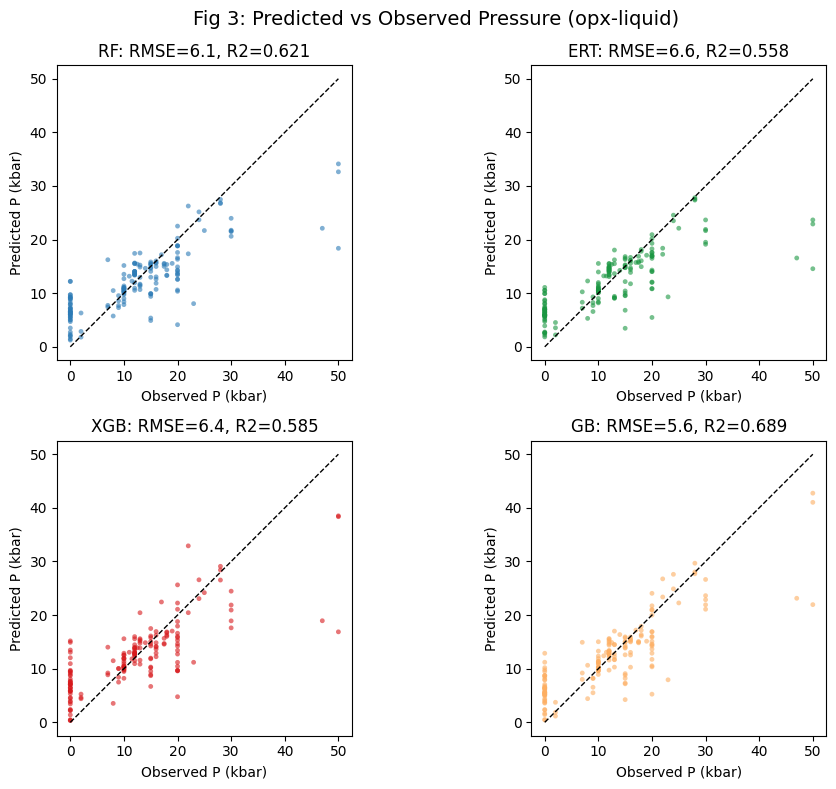

Saved fig03_pred_vs_obs_P.png


In [7]:
# Fig 3: Pred vs Obs for Pressure
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()
models = ['RF', 'ERT', 'XGB', 'GB']
colors = ['#2c7bb6', '#1a9641', '#d7191c', '#fdae61']

for i, model_name in enumerate(models):
    ax = axes[i]
    result = [r for r in all_results if r['target'] == 'P_kbar' and r['model'] == model_name and r['model_type'] == 'opx_liq'][0]
    y_test, p_test = result['y_test'], result['p_test']
    rmse = result['rmse_test']
    r2 = result['r2_test']
    
    ax.scatter(y_test, p_test, c=colors[i], alpha=0.6, s=12, edgecolors='none')
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', linewidth=1)
    ax.set_xlabel('Observed P (kbar)')
    ax.set_ylabel('Predicted P (kbar)')
    ax.set_title(f'{model_name}: RMSE={rmse:.1f}, R2={r2:.3f}')
    ax.set_aspect('equal')

plt.suptitle('Fig 3: Predicted vs Observed Pressure (opx-liquid)', fontsize=14, y=0.98)
plt.tight_layout()
plt.savefig(FIGURES / 'fig03_pred_vs_obs_P.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved fig03_pred_vs_obs_P.png')

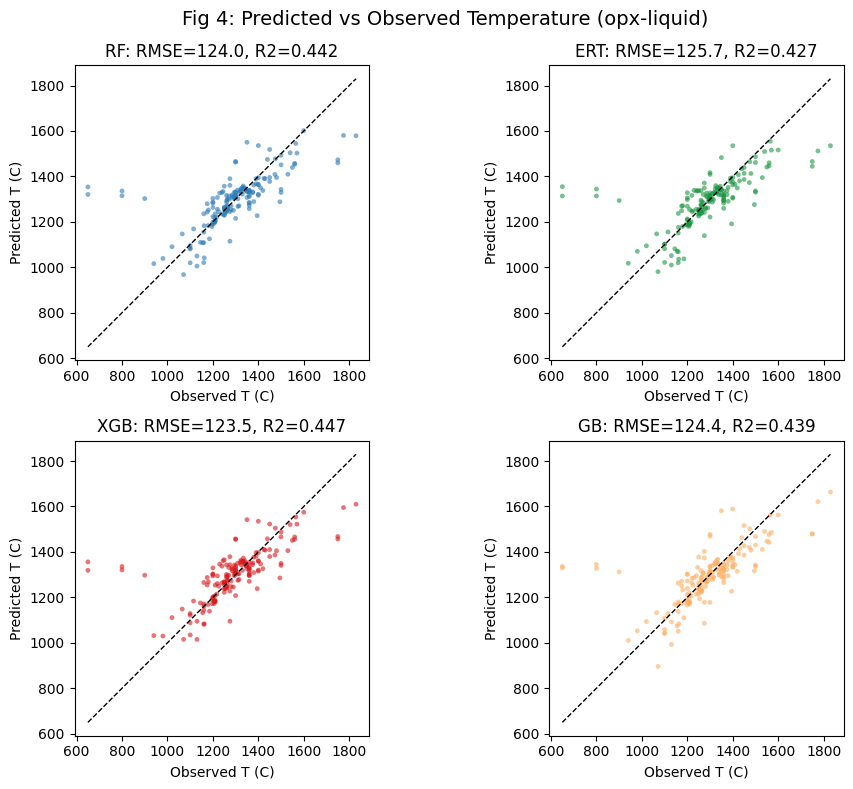

Saved fig04_pred_vs_obs_T.png


In [8]:
# Fig 4: Pred vs Obs for Temperature
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, model_name in enumerate(models):
    ax = axes[i]
    result = [r for r in all_results if r['target'] == 'T_C' and r['model'] == model_name and r['model_type'] == 'opx_liq'][0]
    y_test, p_test = result['y_test'], result['p_test']
    rmse = result['rmse_test']
    r2 = result['r2_test']
    
    ax.scatter(y_test, p_test, c=colors[i], alpha=0.6, s=12, edgecolors='none')
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', linewidth=1)
    ax.set_xlabel('Observed T (C)')
    ax.set_ylabel('Predicted T (C)')
    ax.set_title(f'{model_name}: RMSE={rmse:.1f}, R2={r2:.3f}')
    ax.set_aspect('equal')

plt.suptitle('Fig 4: Predicted vs Observed Temperature (opx-liquid)', fontsize=14, y=0.98)
plt.tight_layout()
plt.savefig(FIGURES / 'fig04_pred_vs_obs_T.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved fig04_pred_vs_obs_T.png')

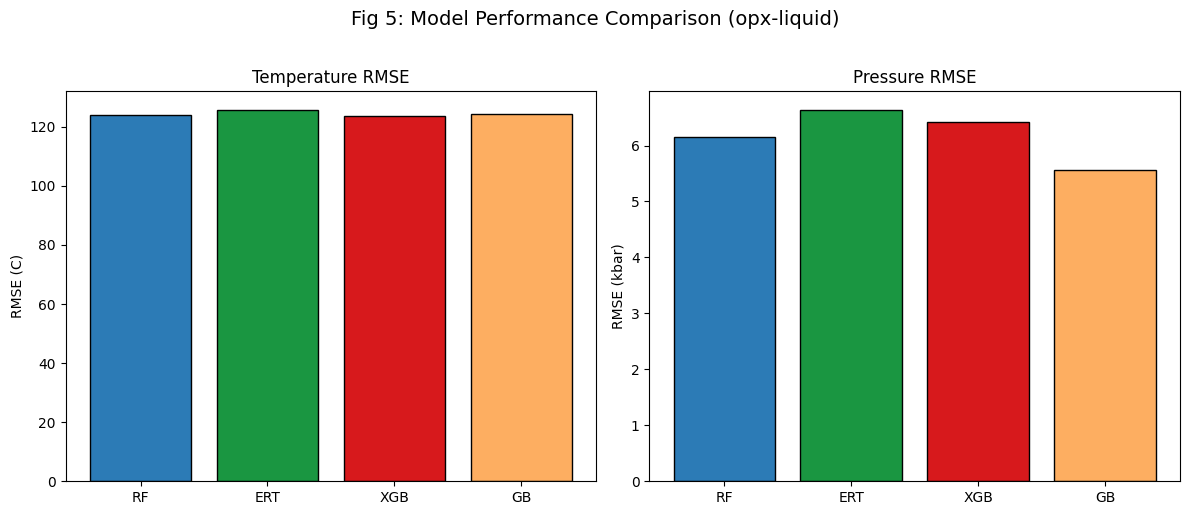

Saved fig05_model_comparison.png

Notebook 03 complete.


In [9]:
# Fig 5: Model comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

t_rmses = [r['rmse_test'] for r in all_results if r['target'] == 'T_C' and r['model_type'] == 'opx_liq']
axes[0].bar(range(4), t_rmses, color=colors, edgecolor='black')
axes[0].set_xticks(range(4))
axes[0].set_xticklabels(models)
axes[0].set_ylabel('RMSE (C)')
axes[0].set_title('Temperature RMSE')

p_rmses = [r['rmse_test'] for r in all_results if r['target'] == 'P_kbar' and r['model_type'] == 'opx_liq']
axes[1].bar(range(4), p_rmses, color=colors, edgecolor='black')
axes[1].set_xticks(range(4))
axes[1].set_xticklabels(models)
axes[1].set_ylabel('RMSE (kbar)')
axes[1].set_title('Pressure RMSE')

plt.suptitle('Fig 5: Model Performance Comparison (opx-liquid)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / 'fig05_model_comparison.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved fig05_model_comparison.png')
print('\nNotebook 03 complete.')